# 03 - Training with Explicit Autograd Loop

This notebook demonstrates gradient-based optimization using:
- `qc.expvals(thetas)` (the `Circuit` builder API) as model output
- standard PyTorch loss/backward/optimizer step

Why explicit loop:
- easier debugging of `requires_grad`, gradient norms, and training stability
- no hidden training helper logic

In [2]:
# EN: Minimal training notebook setup: padopauli plus PyTorch.
# KO: 가장 단순한 학습 노트북 구성을 위해 padopauli와 PyTorch만 먼저 준비합니다.

import warnings
warnings.filterwarnings("ignore")

import torch

from padopauli import Circuit

In [3]:
n_qubits = 3

# Rotation + CNOT-ladder circuit (0->1->2 repeated), built with the Circuit builder API.
qc = Circuit(n_qubits=n_qubits)
idx = 0

# Layer 0: local rotations
for q in range(n_qubits):
    qc.rz(q, param_idx=idx); idx += 1
for q in range(n_qubits):
    qc.rx(q, param_idx=idx); idx += 1
# CNOT ladder
qc.cnot(0, 1)
qc.cnot(1, 2)

# Layer 1: local rotations
for q in range(n_qubits):
    qc.rz(q, param_idx=idx); idx += 1
for q in range(n_qubits):
    qc.ry(q, param_idx=idx); idx += 1
# CNOT ladder (reverse)
qc.cnot(1, 2)
qc.cnot(0, 1)

# Layer 2: final rotations
qc.rx(0, param_idx=idx); idx += 1
qc.ry(1, param_idx=idx); idx += 1
qc.rz(2, param_idx=idx); idx += 1

# One single-term observable <Z_q> per qubit, written as (pauli, qubits) tuples.
obs = [("Z", [q]) for q in range(n_qubits)]

# Device-aware setup: GPU preset when CUDA is available, CPU preset otherwise.
use_cuda = torch.cuda.is_available()
dev = "cuda" if use_cuda else "cpu"
nb_preset = "gpu" if use_cuda else "cpu"

torch.manual_seed(0)  # reproducible trainable-parameter init
thetas = torch.nn.Parameter(torch.randn(qc.n_params, dtype=torch.float32, device=dev))
program = qc.compile(observables=obs, preset=nb_preset)

propagate:   0%|          | 0/19 [00:00<?, ?it/s]

[PPS Info] Propagation complete. Terms generated: 62


zero-filter:   0%|          | 0/19 [00:00<?, ?it/s]

[PPS Info] Terms retained after pruning: 6 (9.677419% of peak)


## Optimize parameters against target expectations

Key tensors:
- `thetas`: trainable circuit parameters
- `target`: desired expectation vector
- `pred`: model prediction from compiled surrogate
- `loss`: distance between `pred` and `target`

Build-time pruning (`build_min_abs`) can remove parameter paths and make `pred` non-differentiable away from `build_thetas`, so it is left off for training. `pred.requires_grad` must be `True`; otherwise parameter paths were pruned at build time.


In [4]:
# Trainable parameters
optimizer = torch.optim.Adam([thetas], lr=0.01)

target = torch.tensor([0.2, -0.1, 0.5], dtype=torch.float32, device=dev)

final loss: 2.1691070839349805e-14
final grad_norm: 1.48909848007861e-07
final thetas: tensor([-0.9247, -0.4253, -2.6438,  0.7116,  0.1892, -0.4444,  0.0242,  0.2329,
        -1.1532, -0.8918, -2.1144,  2.3678,  0.8185,  0.4202,  1.2866])
pred: tensor([ 0.2000, -0.1000,  0.5000], dtype=torch.float64)


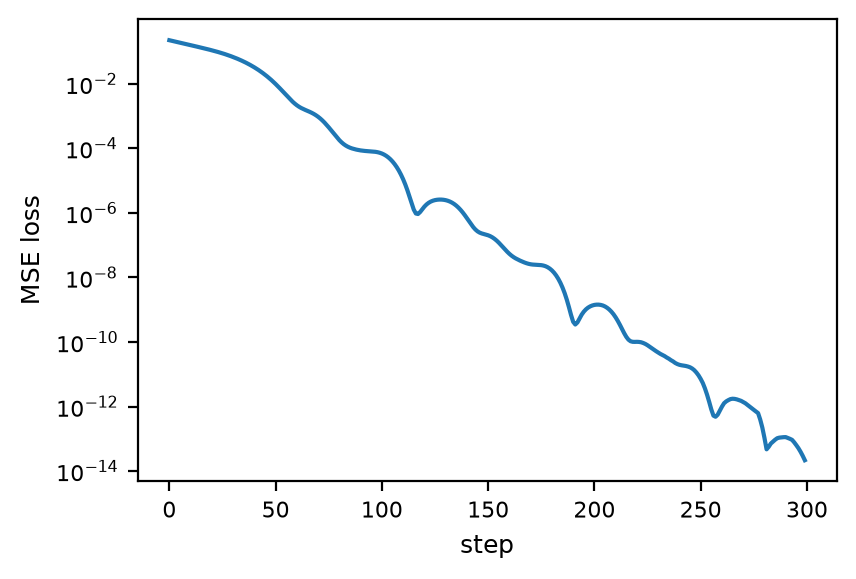

In [5]:
num_steps = 300
history = []

for step in range(num_steps):
    optimizer.zero_grad(set_to_none=True)

    pred = qc.expvals(thetas)
    loss_t = torch.mean((pred - target) ** 2)

    if not bool(pred.requires_grad):
        raise RuntimeError(
            "pred does not require gradients. If you compiled with build_min_abs, recompile without build_min_abs (or use a much smaller threshold)."
        )

    loss_t.backward()
    if thetas.grad is None:
        raise RuntimeError("No gradient on thetas after backward().")

    grad_norm = torch.linalg.vector_norm(thetas.grad.detach())
    optimizer.step()

    history.append(float(loss_t.detach().cpu().item()))

print("final loss:", history[-1])
print("final grad_norm:", float(grad_norm.detach().cpu().item()))
print("final thetas:", thetas.detach().cpu())
print("pred:", pred.detach().cpu())

from matplotlib import pyplot as plt
plt.rcParams.update({"font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
                     "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
                     "figure.dpi": 200, "savefig.dpi": 200})
plt.figure(figsize=(4.51, 3.0))
plt.plot(history)
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("MSE loss")
import os as _os; _os.makedirs("figures", exist_ok=True); plt.savefig("figures/fig_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Build-time pruning sweep: build_min_abs vs size/speed
import time

def _step_nnz(psum):
    total = 0
    for st in psum.steps:
        total += int(st.mat_const._nnz()) + int(st.mat_cos._nnz()) + int(st.mat_sin._nnz())
    return total

def _time_eval(prog, th, runs=50):
    _ = prog.expvals(th)
    t0 = time.perf_counter()
    for _ in range(runs):
        _ = prog.expvals(th)
    return (time.perf_counter() - t0) / runs

theta_build = thetas.detach().cpu().to(torch.float32)
theta_train = torch.nn.Parameter(theta_build.clone())
target_cpu = target.detach().cpu().to(torch.float32)

configs = [None, 1e-7, 1e-6, 1e-5]

rows = []
for b_abs in configs:
    t0 = time.perf_counter()
    prog = qc.compile(
        observables=obs,
        preset=nb_preset,
        build_thetas=theta_build,
        build_min_abs=b_abs,
    )
    compile_s = time.perf_counter() - t0

    nnz = _step_nnz(prog.psum_union)
    eval_ms = 1e3 * _time_eval(prog, theta_build, runs=50)

    # one-step grad sanity
    th = torch.nn.Parameter(theta_train.detach().clone())
    pred = prog.expvals(th)
    loss = torch.mean((pred.cpu() - target_cpu) ** 2)
    loss.backward()
    grad_ok = th.grad is not None and bool(pred.requires_grad)

    rows.append((b_abs, compile_s, nnz, eval_ms, float(loss.detach()), grad_ok))

print('build_min_abs | compile(s) | total_nnz | eval(ms) | loss | grad_ok')
for r in rows:
    print(f'{str(r[0]):>12} | {r[1]:9.3f} | {r[2]:9d} | {r[3]:8.3f} | {r[4]:.3e} | {r[5]}')

propagate:   0%|          | 0/19 [00:00<?, ?it/s]

[PPS Info] Propagation complete. Terms generated: 62


zero-filter:   0%|          | 0/19 [00:00<?, ?it/s]

[PPS Info] Terms retained after pruning: 6 (9.677419% of peak)


propagate:   0%|          | 0/19 [00:00<?, ?it/s]

...

[PPS Info] Terms retained after pruning: 6 (9.677419% of peak)


propagate:   0%|          | 0/19 [00:00<?, ?it/s]

[PPS Info] Propagation complete. Terms generated: 62


zero-filter:   0%|          | 0/19 [00:00<?, ?it/s]

[PPS Info] Terms retained after pruning: 6 (9.677419% of peak)
build_min_abs | compile(s) | total_nnz | eval(ms) | loss | grad_ok
        None |     0.037 |        69 |    1.239 | 1.469e-14 | True
       1e-07 |     0.095 |        69 |    1.246 | 1.469e-14 | True
       1e-06 |     0.039 |        69 |    1.240 | 1.469e-14 | True
       1e-05 |     0.038 |        69 |    1.251 | 1.469e-14 | True


## Reading the sweep

The sweep reports compile time, nnz, eval latency, loss level, and gradient availability for each `build_min_abs` (compile-time theta-dependent path pruning). Use it to choose pruning that still preserves trainability.

### Build-time pruning trade-off (`build_min_abs`)

`build_min_abs` drops low-magnitude coefficient paths at compile time. On a larger circuit (so `max_weight=10` is a real cap), raising the threshold increases the deviation from the exact statevector while shrinking the retained evaluation working set — the inference-time accuracy/cost trade-off.

propagate:   0%|          | 0/248 [00:00<?, ?it/s]

[PPS Info] Propagation complete. Terms generated: 7,157


zero-filter:   0%|          | 0/248 [00:00<?, ?it/s]

[PPS Info] Terms retained after pruning: 92 (1.285455% of peak)


propagate:   0%|          | 0/248 [00:00<?, ?it/s]

...

[PPS Info] Terms retained after pruning: 74 (1.399130% of peak)


propagate:   0%|          | 0/248 [00:00<?, ?it/s]

[PPS Info] Propagation complete. Terms generated: 3,241


zero-filter:   0%|          | 0/248 [00:00<?, ?it/s]

[PPS Info] Terms retained after pruning: 56 (1.727862% of peak)
build_min_abs=  None | |tensor-exact|=7.772e-15 | retained terms=6470
build_min_abs= 1e-06 | |tensor-exact|=1.333e-06 | retained terms=5674
build_min_abs= 1e-05 | |tensor-exact|=9.400e-06 | retained terms=4820
build_min_abs=0.0001 | |tensor-exact|=2.491e-04 | retained terms=3535


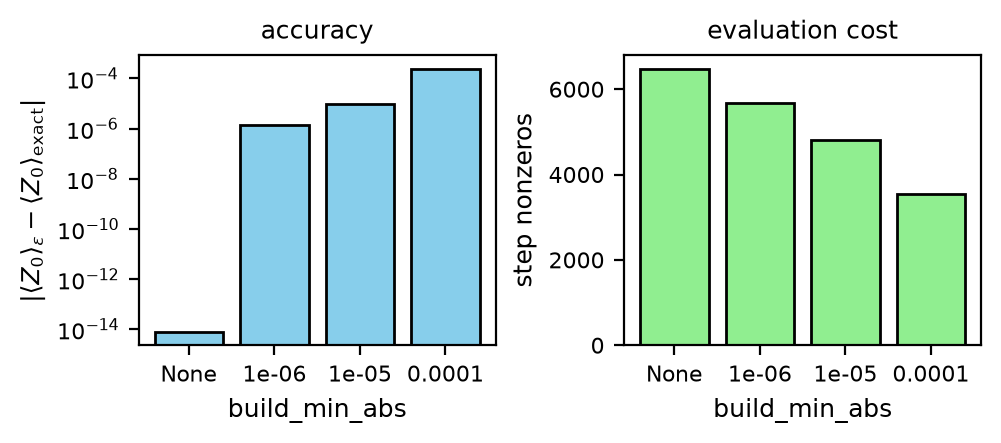

In [7]:
# Build-time coefficient pruning (build_min_abs) at fixed max_weight=10:
# accuracy vs the exact statevector (left) and the retained evaluation working set (right).
import time
import matplotlib.pyplot as plt

torch.manual_seed(0)
bma_nq = 16
bma_qc = Circuit(n_qubits=bma_nq)
_p = 0
for _pauli in ["Y", "Z", "X", "Y", "Z", "X", "Y", "Z"]:
    for _q in range(bma_nq):
        bma_qc.rot(_pauli, [_q], param_idx=_p); _p += 1
    for _q in range(bma_nq - 1):
        bma_qc.cnot(_q, _q + 1)
bma_theta = 1.1 * torch.randn(_p, dtype=torch.float64)
bma_obs = ("Z", [0])  # single-term observable as a (pauli, qubits) tuple

# exact <Z_0> via the Circuit's own PennyLane statevector cross-check (expvals_reference
# ignores build_min_abs pruning, so a plain, unpruned compile is enough to call it).
bma_qc.compile(observables=[bma_obs], preset=nb_preset, max_weight=10)
bma_exact = float(bma_qc.expvals_reference(bma_theta)[0])

def _retained_terms(prog):
    return sum(int(s.mat_const._nnz()) + int(s.mat_cos._nnz()) + int(s.mat_sin._nnz())
               for s in prog.psum_union.steps)

bma_values = [None, 1e-6, 1e-5, 1e-4]
bma_dev, bma_terms = [], []
for _bma in bma_values:
    _prog = bma_qc.compile(
        observables=[bma_obs], preset=nb_preset, max_weight=10,
        build_thetas=bma_theta, build_min_abs=_bma)
    bma_dev.append(abs(float(_prog.expvals(bma_theta)[0]) - bma_exact))
    bma_terms.append(_retained_terms(_prog))

for _b, _d, _t in zip(bma_values, bma_dev, bma_terms):
    print(f"build_min_abs={str(_b):>6} | |tensor-exact|={_d:.3e} | retained terms={_t}")

_labels = [str(b) for b in bma_values]
fig, ax = plt.subplots(1, 2, figsize=(4.89, 2.1), constrained_layout=True)
ax[0].bar(_labels, bma_dev, color="skyblue", edgecolor="black")
ax[0].set_yscale("log"); ax[0].set_title("accuracy")
ax[0].set_ylabel(r"$|\langle Z_0\rangle_\epsilon - \langle Z_0\rangle_{\rm exact}|$"); ax[0].set_xlabel("build_min_abs")
ax[1].bar(_labels, bma_terms, color="lightgreen", edgecolor="black")
ax[1].set_title("evaluation cost")
ax[1].set_ylabel("step nonzeros"); ax[1].set_xlabel("build_min_abs")
import os as _os; _os.makedirs("figures", exist_ok=True); plt.savefig("figures/fig_build_min_abs.png", dpi=150, bbox_inches="tight")
plt.show()